In [2]:
#Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# imports
import os, time, copy, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import OneCycleLR
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [4]:
DATA_ROOT = '/content/drive/MyDrive/Datasets/NewPlant/processed'
IMG_SIZE     = 224
BATCH_SIZE   = 64
NUM_EPOCHS   = 40
LR_MAX       = 3e-3
WEIGHT_DECAY = 1e-4
LABEL_SMOOTH = 0.1
DROPOUT_P    = 0.3
NUM_WORKERS  = 2

NUM_CLASSES = len(os.listdir(os.path.join(DATA_ROOT, 'train')))
print(f'Classes found: {NUM_CLASSES}')

Classes found: 6


In [5]:
#Transforms
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.6, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3, hue=0.05),
    transforms.RandomRotation(20),
    transforms.RandomGrayscale(p=0.05),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.15)),
])

val_tf = transforms.Compose([
    transforms.Resize(int(IMG_SIZE * 1.14)),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

In [6]:
# Datasets & Loaders
train_ds = datasets.ImageFolder(os.path.join(DATA_ROOT, 'train'), transform=train_tf)
val_ds   = datasets.ImageFolder(os.path.join(DATA_ROOT, 'val'),   transform=val_tf)

class_counts   = np.bincount(train_ds.targets)
class_weights  = 1.0 / class_counts
sample_weights = class_weights[train_ds.targets]
sampler = WeightedRandomSampler(sample_weights, len(sample_weights), replacement=True)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE,
                      sampler=sampler, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                      shuffle=False, num_workers=NUM_WORKERS,
                      pin_memory=True, persistent_workers=True)

print(f'Train: {len(train_ds)} | Val: {len(val_ds)}')
print(f'Classes: {train_ds.classes}')

Train: 11118 | Val: 1391
Classes: ['Bacterial Spot', 'Early Blight', 'Healthy', 'Late Blight', 'Septoria Leaf Spot', 'Yellow Leaf Curl Virus']


In [7]:
import torch.nn as nn
import torch.nn.functional as F

def conv_3x3_bn(in_ch, out_ch, stride):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 3, stride, 1, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU6(inplace=True) # ReLU6 is used in MobileNetV2 for better quantization
    )

def conv_1x1_bn(in_ch, out_ch):
    return nn.Sequential(
        nn.Conv2d(in_ch, out_ch, 1, 1, 0, bias=False),
        nn.BatchNorm2d(out_ch),
        nn.ReLU6(inplace=True)
    )

class InvertedResidual(nn.Module):
    def __init__(self, in_ch, out_ch, stride, expand_ratio):
        super().__init__()
        self.stride = stride
        hidden_dim = int(round(in_ch * expand_ratio))
        self.use_res_connect = self.stride == 1 and in_ch == out_ch

        layers = []
        if expand_ratio != 1:
            # pw (point-wise expansion)
            layers.append(conv_1x1_bn(in_ch, hidden_dim))

        layers.extend([
            # dw (depth-wise convolution)
            nn.Conv2d(hidden_dim, hidden_dim, 3, stride, 1, groups=hidden_dim, bias=False),
            nn.BatchNorm2d(hidden_dim),
            nn.ReLU6(inplace=True),
            # pw-linear (point-wise compression back to out_ch)
            nn.Conv2d(hidden_dim, out_ch, 1, 1, 0, bias=False),
            nn.BatchNorm2d(out_ch),
        ])
        self.conv = nn.Sequential(*layers)

    def forward(self, x):
        if self.use_res_connect:
            return x + self.conv(x)
        else:
            return self.conv(x)

class MobileNetV2(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT_P):
        super().__init__()
        # MobileNetV2 configuration: [expansion, out_channels, num_blocks, stride]
        self.config = [
            [1, 16,  1, 1],
            [6, 24,  2, 2],
            [6, 32,  3, 2],
            [6, 64,  4, 2],
            [6, 96,  3, 1],
            [6, 160, 3, 2],
            [6, 320, 1, 1],
        ]

        # Stem layer
        input_channel = 32
        self.stem = conv_3x3_bn(3, input_channel, 2)

        # Build Inverted Residual Blocks
        layers = []
        for t, c, n, s in self.config:
            for i in range(n):
                stride = s if i == 0 else 1
                layers.append(InvertedResidual(input_channel, c, stride, expand_ratio=t))
                input_channel = c
        self.blocks = nn.Sequential(*layers)

        # Final layers
        last_channel = 1280
        self.last_conv = conv_1x1_bn(input_channel, last_channel)
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(dropout)
        self.classifier = nn.Linear(last_channel, num_classes)

        # Weight initialization
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.ones_(m.weight); nn.init.zeros_(m.bias)
            elif isinstance(m, nn.Linear):
                nn.init.normal_(m.weight, 0, 0.01); nn.init.zeros_(m.bias)

    def forward(self, x):
        x = self.stem(x)
        x = self.blocks(x)
        x = self.last_conv(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        return self.classifier(x)

# Initialize the model
model = MobileNetV2().to(DEVICE)
total = sum(p.numel() for p in model.parameters())
print(f'Total parameters: {total/1e6:.2f}M')

Total parameters: 2.23M


In [8]:
# Loss / Optimizer / Scheduler
criterion = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTH)

optimizer = AdamW(model.parameters(), lr=LR_MAX / 25, weight_decay=WEIGHT_DECAY)

scheduler = OneCycleLR(
    optimizer,
    max_lr=LR_MAX,
    steps_per_epoch=len(train_dl),
    epochs=NUM_EPOCHS,
    pct_start=0.3,
    anneal_strategy='cos',
    div_factor=25,
    final_div_factor=1e4
)

scaler = GradScaler()

In [9]:
#training loop
# replace your training loop cell with this

from tqdm import tqdm

def run_epoch(model, loader, criterion, optimizer, scheduler, scaler, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0

    desc = 'Train' if train else 'Val'
    pbar = tqdm(loader, desc=desc, leave=False, ncols=80)

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for imgs, labels in pbar:
            imgs   = imgs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)

            if train:
                optimizer.zero_grad(set_to_none=True)
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                scaler.step(optimizer)
                scaler.update()
                scheduler.step()
            else:
                with autocast():
                    out  = model(imgs)
                    loss = criterion(out, labels)

            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)

            pbar.set_postfix(loss=f'{total_loss/total:.4f}',
                             acc=f'{correct/total:.2%}')

    return total_loss / total, correct / total


history = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_acc, best_wts = 0.0, copy.deepcopy(model.state_dict())

for epoch in range(1, NUM_EPOCHS + 1):
    t0 = time.time()
    tr_loss, tr_acc = run_epoch(model, train_dl, criterion, optimizer, scheduler, scaler, train=True)
    va_loss, va_acc = run_epoch(model, val_dl,   criterion, optimizer, scheduler, scaler, train=False)
    elapsed = time.time() - t0

    history['train_loss'].append(tr_loss); history['val_loss'].append(va_loss)
    history['train_acc'].append(tr_acc);   history['val_acc'].append(va_acc)

    if va_acc > best_acc:
        best_acc = va_acc
        best_wts = copy.deepcopy(model.state_dict())
        tag = ' ★'
    else:
        tag = ''


    torch.save({
        'epoch': epoch,
        'model_state': model.state_dict(),
        'optimizer_state': optimizer.state_dict(),
        'best_val_acc': best_acc,
        'history': history
    }, '/content/drive/MyDrive/Datasets/NewPlant/mobilenet_checkpoint_latest.pth')

    print(f'  checkpoint saved (epoch {epoch})')

    print(f'Epoch {epoch:>3}  '
          f'TrLoss={tr_loss:.4f}  TrAcc={tr_acc:.2%}  '
          f'VaLoss={va_loss:.4f}  VaAcc={va_acc:.2%}  '
          f'{elapsed:.0f}s{tag}')

print(f'\nBest val accuracy: {best_acc:.4%}')

  checkpoint saved (epoch 1)
Epoch   1  TrLoss=1.6284  TrAcc=33.94%  VaLoss=1.3331  VaAcc=52.41%  1212s ★


  checkpoint saved (epoch 2)
Epoch   2  TrLoss=1.3161  TrAcc=54.89%  VaLoss=1.1746  VaAcc=62.26%  415s ★


  checkpoint saved (epoch 3)
Epoch   3  TrLoss=1.1833  TrAcc=61.84%  VaLoss=1.2737  VaAcc=60.10%  225s


  checkpoint saved (epoch 4)
Epoch   4  TrLoss=1.1038  TrAcc=66.49%  VaLoss=0.9654  VaAcc=73.98%  160s ★


  checkpoint saved (epoch 5)
Epoch   5  TrLoss=1.0462  TrAcc=69.85%  VaLoss=1.0263  VaAcc=71.82%  142s


...

  checkpoint saved (epoch 36)
Epoch  36  TrLoss=0.4751  TrAcc=97.72%  VaLoss=0.4434  VaAcc=98.99%  128s


  checkpoint saved (epoch 37)
Epoch  37  TrLoss=0.4837  TrAcc=97.39%  VaLoss=0.4454  VaAcc=98.71%  128s


  checkpoint saved (epoch 38)
Epoch  38  TrLoss=0.4785  TrAcc=97.55%  VaLoss=0.4417  VaAcc=98.99%  127s


  checkpoint saved (epoch 39)
Epoch  39  TrLoss=0.4788  TrAcc=97.49%  VaLoss=0.4383  VaAcc=99.21%  125s ★


  checkpoint saved (epoch 40)
Epoch  40  TrLoss=0.4773  TrAcc=97.63%  VaLoss=0.4410  VaAcc=99.07%  129s

Best val accuracy: 99.2092%


In [10]:
torch.save({
    'model_state': best_wts,
    'classes': train_ds.classes,
    'best_val_acc': best_acc
}, '/content/drive/MyDrive/Datasets/NewPlant/mobilenet_best.pth')
print(f'Saved best model with val acc: {best_acc:.4%}')

Saved best model with val acc: 99.2092%


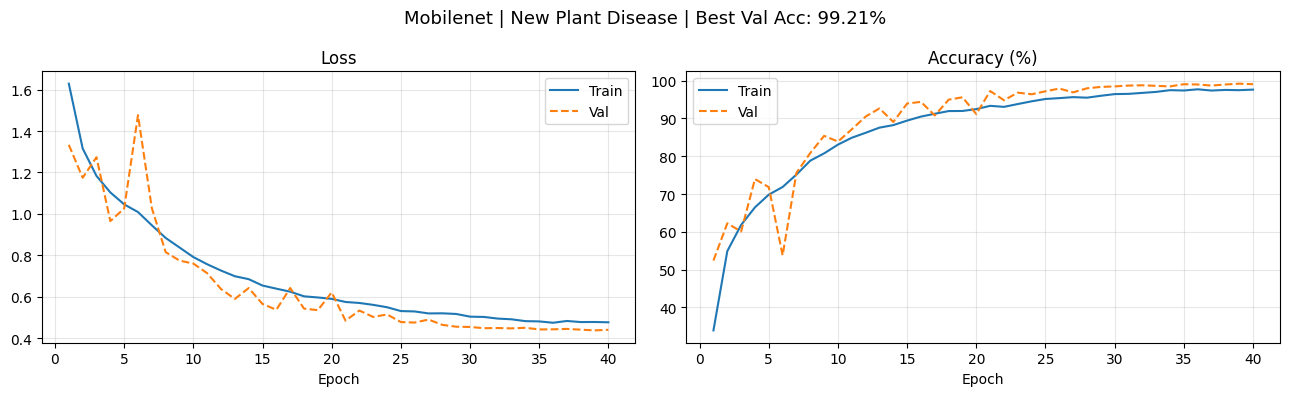

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
ep = range(1, len(history['train_loss']) + 1)

axes[0].plot(ep, history['train_loss'], label='Train')
axes[0].plot(ep, history['val_loss'],   label='Val', linestyle='--')
axes[0].set_title('Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(ep, [a*100 for a in history['train_acc']], label='Train')
axes[1].plot(ep, [a*100 for a in history['val_acc']],   label='Val', linestyle='--')
axes[1].set_title('Accuracy (%)'); axes[1].set_xlabel('Epoch')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle(f'Mobilenet | New Plant Disease | Best Val Acc: {best_acc:.2%}', fontsize=13)
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/NewPlant/mobilenet_curves.png', dpi=150)
plt.show()

In [12]:
test_path = os.path.join(DATA_ROOT, 'test')
eval_path = test_path if os.path.exists(test_path) else os.path.join(DATA_ROOT, 'val')

eval_ds = datasets.ImageFolder(eval_path, transform=val_tf)
eval_dl = DataLoader(eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                     num_workers=0, pin_memory=True)

model.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for imgs, labels in eval_dl:
        with autocast():
            out = model(imgs.to(DEVICE))
        all_preds.append(out.argmax(1).cpu())
        all_labels.append(labels)

all_preds  = torch.cat(all_preds)
all_labels = torch.cat(all_labels)
overall    = (all_preds == all_labels).float().mean().item()
print(f'\nOverall accuracy on {os.path.basename(eval_path)}: {overall:.4%}\n')

for i, cls in enumerate(eval_ds.classes):
    mask = (all_labels == i)
    acc  = (all_preds[mask] == all_labels[mask]).float().mean().item()
    print(f'  {cls:40s}  {acc:6.2%}  (n={mask.sum().item()})')


Overall accuracy on test: 99.4253%

  Bacterial Spot                            99.06%  (n=213)
  Early Blight                              98.76%  (n=241)
  Healthy                                   99.59%  (n=241)
  Late Blight                               99.57%  (n=232)
  Septoria Leaf Spot                        100.00%  (n=219)
  Yellow Leaf Curl Virus                    99.59%  (n=246)


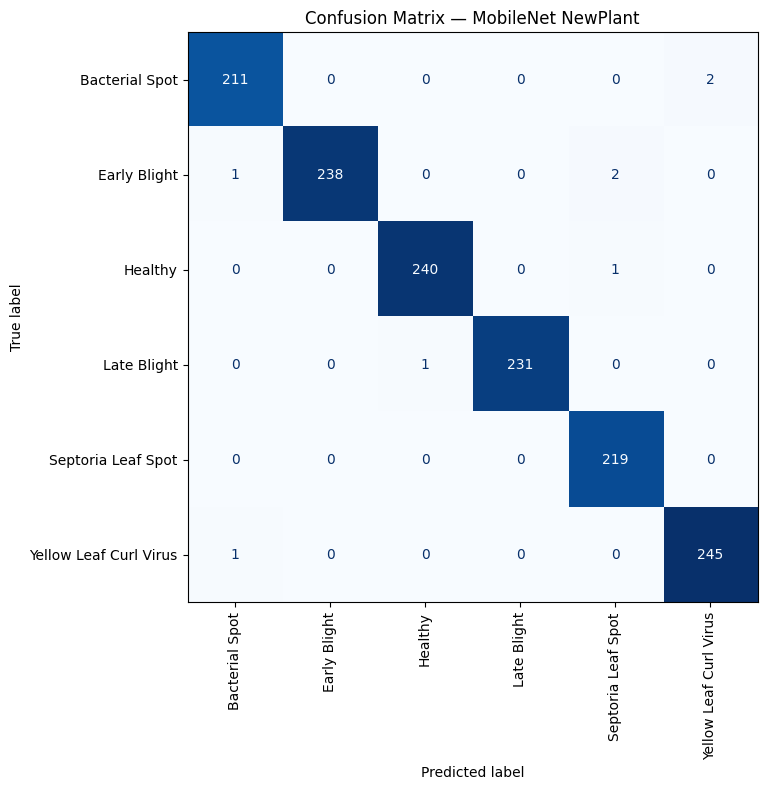

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm   = confusion_matrix(all_labels.numpy(), all_preds.numpy())
fig, ax = plt.subplots(figsize=(max(8, NUM_CLASSES//2), max(8, NUM_CLASSES//2)))
ConfusionMatrixDisplay(cm, display_labels=eval_ds.classes).plot(
    ax=ax, xticks_rotation=90, colorbar=False, cmap='Blues')
plt.title('Confusion Matrix — MobileNet NewPlant')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/Datasets/NewPlant/mobilenet_cm.png', dpi=120)
plt.show()


In [14]:
from sklearn.metrics import classification_report
print(classification_report(all_labels.numpy(), all_preds.numpy(), target_names=eval_ds.classes))

                        precision    recall  f1-score   support

        Bacterial Spot       0.99      0.99      0.99       213
          Early Blight       1.00      0.99      0.99       241
               Healthy       1.00      1.00      1.00       241
           Late Blight       1.00      1.00      1.00       232
    Septoria Leaf Spot       0.99      1.00      0.99       219
Yellow Leaf Curl Virus       0.99      1.00      0.99       246

              accuracy                           0.99      1392
             macro avg       0.99      0.99      0.99      1392
          weighted avg       0.99      0.99      0.99      1392

